<a href="https://colab.research.google.com/github/mymph/ml-project-fairness/blob/main/fairness_fraud_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Projeto: Como o Conjunto de Features Afeta a Equidade do Modelo?**

**Tema 2.1:** Usando 10 bases sintéticas de detecção de fraudes financeiras com diferentes níveis de viés de representação, avalie como o conjunto de features utilizadas afeta a equidade do modelo.

---

##**Metodologia**
- **Modelo:** Regressão Logística
- **Target:** `I-d` (fraude tipo D)
- **Removido:** `I-e` (outro tipo de fraude — evitar data leakage)
- **Atributo protegido:** `RAMO_ATIVIDADE_1` (privilegiado=1, desprivilegiado=4)
- **Métricas:** Acurácia, F1-Score e Disparate Impact (DI)
- **Protocolo:** Treina em 1 base, testa nas outras 9 (10 ciclos)
- **Comparação:** 6 conjuntos de features (F0/F1 pobre, F0/F2 médio, F0/F3 rico — com e sem atributo protegido)

##**Cenários de Features**

| Cenário | Com atributo protegido? | Nível | Hipótese |
|---------|------------------------|-------|----------|
| F0_pobre_ignorance | Não | Pobre | Ignorance (paper) |
| F1_pobre | Sim | Pobre | Baseline |
| F0_medio_ignorance | Não | Médio | Ignorance + temporais |
| F2_medio | Sim | Médio | Temporais |
| F0_rico_ignorance | Não | Rico | Ignorance + proxies? |
| F3_rico | Sim | Rico | Agregações como proxies |

##**Referência**
- "Ignorance and Prejudice" in Software Fairness (ICSE 2021)

#**Instalação e Imports**

In [1]:
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore', category=pd.errors.DtypeWarning)

RANDOM_STATE = 42
TARGET = 'I-d'
PROTECTED = 'RAMO_ATIVIDADE_1'
PRIV_GROUP = [{PROTECTED: 1}]
UNPRIV_GROUP = [{PROTECTED: 4}]

#**1. Carregar as dez bases**

In [2]:
uploaded = files.upload()
base_paths = {name.split('.')[0]: f'/content/{name}' for name in uploaded.keys()}
bases_raw = {}
for name, path in base_paths.items():
    bases_raw[name] = pd.read_csv(path)
    print(f'{name}: {bases_raw[name].shape}')

Saving gs_v0.csv to gs_v0.csv
Saving gs_v0_5.csv to gs_v0_5.csv
Saving gs_v0_25.csv to gs_v0_25.csv
Saving gs_v0_75.csv to gs_v0_75.csv
Saving gs_v1.csv to gs_v1.csv
Saving pd_v0.csv to pd_v0.csv
Saving pd_v0_5.csv to pd_v0_5.csv
Saving pd_v0_25.csv to pd_v0_25.csv
Saving pd_v0_75.csv to pd_v0_75.csv
Saving pd_v1.csv to pd_v1.csv
gs_v0: (148123, 15)
gs_v0_5: (159481, 15)
gs_v0_25: (159481, 15)
gs_v0_75: (159481, 15)
gs_v1: (131008, 15)
pd_v0: (169144, 15)
pd_v0_5: (148752, 15)
pd_v0_25: (168219, 15)
pd_v0_75: (147264, 15)
pd_v1: (149991, 15)


#**2. Análise Exploratória (resumo)**

In [3]:
summary_rows = []

for name, df in bases_raw.items():
    total = len(df)
    fraude = df[TARGET].sum()
    priv = (df[PROTECTED] == 1).sum()
    unpriv = (df[PROTECTED] == 4).sum()
    fraude_priv = df.loc[df[PROTECTED] == 1, TARGET].mean() if priv > 0 else np.nan
    fraude_unpriv = df.loc[df[PROTECTED] == 4, TARGET].mean() if unpriv > 0 else np.nan
    summary_rows.append({
        'Base': name,
        'Tipo Vies': 'group_size' if 'gs_' in name else 'prevalence_disparity',
        'Total': total, 'Fraudes': fraude,
        '% Fraude': round(fraude/total*100, 2),
        'Grupo Priv (1)': priv, 'Grupo Unpriv (4)': unpriv,
        'Ratio Priv/Unpriv': round(priv / unpriv, 3) if unpriv > 0 else np.nan,
        '% Fraude Priv': round(fraude_priv * 100, 2) if not np.isnan(fraude_priv) else np.nan,
        '% Fraude Unpriv': round(fraude_unpriv * 100, 2) if not np.isnan(fraude_unpriv) else np.nan,
    })

summary_df = pd.DataFrame(summary_rows)
summary_df

,Base,Tipo Vies,Total,Fraudes,% Fraude,Grupo Priv (1),Grupo Unpriv (4),Ratio Priv/Unpriv,% Fraude Priv,% Fraude Unpriv
0,gs_v0,group_size,148123,26552,17.93,23508,27855,0.844,19.33,24.87
1,gs_v0_5,group_size,159481,34326,21.52,10644,98488,0.108,30.03,24.61
2,gs_v0_25,group_size,159481,34326,21.52,16395,56613,0.290,32.30,23.34
3,gs_v0_75,group_size,159481,34326,21.52,3618,126437,0.029,0.00,22.52
4,gs_v1,group_size,131008,20168,15.39,0,131008,0.000,NaN,15.39
5,pd_v0,prevalence_disparity,169144,39232,23.19,32334,18645,1.734,28.26,8.11
6,pd_v0_5,prevalence_disparity,148752,23127,15.55,61201,22949,2.667,1.56,69.68
7,pd_v0_25,prevalence_disparity,168219,42456,25.24,49307,19116,2.579,15.72,50.76
8,pd_v0_75,prevalence_disparity,147264,29280,19.88,74602,34966,2.134,3.99,75.23
9,pd_v1,prevalence_disparity,149991,30185,20.12,82719,34498,2.398,0.00,87.50


##**2.1) DI nos dados crus (antes de treinar modelo)**

Resultados desproporcionais para os diferentes grupos antes de ser realizado o treinamento do modelo.


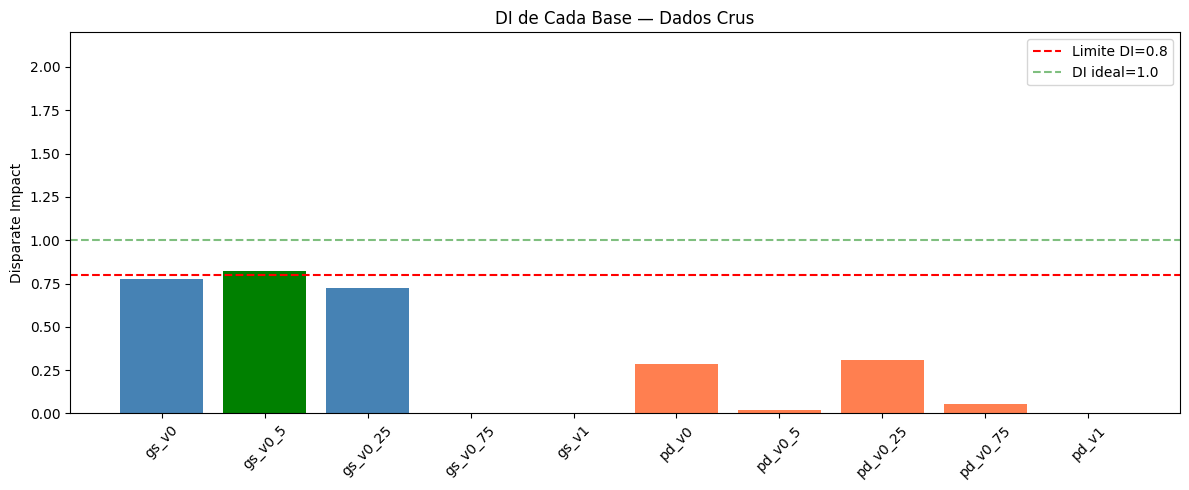

In [4]:
def di_dados_crus(df):
    priv_mask = df[PROTECTED] == 1
    unpriv_mask = df[PROTECTED] == 4
    if priv_mask.sum() == 0 or unpriv_mask.sum() == 0:
        return np.nan
    p_priv = df.loc[priv_mask, TARGET].mean()
    p_unpriv = df.loc[unpriv_mask, TARGET].mean()
    if p_priv == 0:
        return 1.0 if p_unpriv == 0 else 0.0
    di = p_unpriv / p_priv
    if di > 1:
        di = 1 / di
    return di

vies_bases = {}
for name, df in bases_raw.items():
    vies_bases[name] = di_dados_crus(df)

plt.figure(figsize=(12, 5))
colors = []
for name, v in vies_bases.items():
    if 0.8 <= v <= 1.25:
        colors.append('green')
    elif 'gs_' in name:
        colors.append('steelblue')
    else:
        colors.append('coral')

di_values = [min(v, 2.0) if not np.isnan(v) else 0 for v in vies_bases.values()]
bars = plt.bar(vies_bases.keys(), di_values, color=colors)

for bar, (name, di) in zip(bars, vies_bases.items()):
    if di > 2.0:
        plt.text(bar.get_x() + bar.get_width()/2, 2.05, f'DI={di:.1f}', ha='center', fontsize=8, color='red')

plt.axhline(0.8, color='red', linestyle='--', label='Limite DI=0.8')
plt.axhline(1.0, color='green', linestyle='--', alpha=0.5, label='DI ideal=1.0')
plt.ylim(0, 2.2)
plt.title('DI de Cada Base — Dados Crus')
plt.ylabel('Disparate Impact')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#**3. Feature Engineering**

In [5]:
def feature_engineering(df):
    df = df.copy()
    df['DATA_LANCAMENTO'] = pd.to_datetime(df['DATA_LANCAMENTO'])
    df['NATUREZA_COD'] = (df['NATUREZA_LANCAMENTO'] == 'D').astype(int)
    df['dia_semana'] = df['DATA_LANCAMENTO'].dt.dayofweek
    df['mes'] = df['DATA_LANCAMENTO'].dt.month
    df['hora'] = df['DATA_LANCAMENTO'].dt.hour
    df['is_weekend'] = df['dia_semana'].isin([5, 6]).astype(int)
    df['is_madrugada'] = df['hora'].between(0, 5).astype(int)
    df['dia_do_mes'] = df['DATA_LANCAMENTO'].dt.day
    df['is_inicio_mes'] = (df['dia_do_mes'] <= 5).astype(int)
    df['is_fim_mes'] = (df['dia_do_mes'] >= 25).astype(int)
    grp = df.groupby('NUMERO_CONTA')
    df['tx_count_conta'] = grp['VALOR_TRANSACAO'].transform('count')
    df['valor_medio_conta'] = grp['VALOR_TRANSACAO'].transform('mean')
    df['valor_total_conta'] = grp['VALOR_TRANSACAO'].transform('sum')
    df['valor_std_conta'] = grp['VALOR_TRANSACAO'].transform('std').fillna(0)
    df['data_dia'] = df['DATA_LANCAMENTO'].dt.date
    df['dias_ativos_conta'] = grp['data_dia'].transform('nunique')
    df['qtd_cnpjs_od'] = grp['CPF_CNPJ_OD'].transform('nunique')
    df['qtd_contas_od'] = grp['NUMERO_CONTA_OD'].transform('nunique')
    df['valor_over_media'] = df['VALOR_TRANSACAO'] / (df['valor_medio_conta'] + 1e-6)
    df = df.drop(columns=['data_dia'], errors='ignore')

    return df

bases = {}
for name, df in bases_raw.items():
    bases[name] = feature_engineering(df)

##**3.1) Definir os conjuntos de features (com e sem atributo protegido)**

In [6]:
F1 = ['VALOR_TRANSACAO', 'CNAB', 'VALOR_SALDO', 'NATUREZA_COD', 'RAMO_ATIVIDADE_1']
F2 = F1 + ['dia_semana', 'mes', 'hora', 'is_weekend', 'is_madrugada', 'dia_do_mes', 'is_inicio_mes', 'is_fim_mes']
F3 = F2 + ['tx_count_conta', 'valor_medio_conta', 'valor_total_conta', 'valor_std_conta', 'dias_ativos_conta', 'qtd_cnpjs_od', 'qtd_contas_od', 'valor_over_media']

F0_pobre = [f for f in F1 if f != 'RAMO_ATIVIDADE_1']
F0_medio = [f for f in F2 if f != 'RAMO_ATIVIDADE_1']
F0_rico  = [f for f in F3 if f != 'RAMO_ATIVIDADE_1']

feature_sets = {
    'F0_pobre_ignorance': F0_pobre,
    'F1_pobre':           F1,
    'F0_medio_ignorance': F0_medio,
    'F2_medio':           F2,
    'F0_rico_ignorance':  F0_rico,
    'F3_rico':            F3,
}

for name, feats in feature_sets.items():
    has_prot = 'RAMO_ATIVIDADE_1' in feats
    print(f'{name}: {len(feats)} features | Attr protegido: {has_prot}')

F0_pobre_ignorance: 4 features | Attr protegido: False
F1_pobre: 5 features | Attr protegido: True
F0_medio_ignorance: 12 features | Attr protegido: False
F2_medio: 13 features | Attr protegido: True
F0_rico_ignorance: 20 features | Attr protegido: False
F3_rico: 21 features | Attr protegido: True


#**4. Cálculo do Disparate Impact**
Viés no modelo

In [7]:
#DI = P(ŷ=1|unpriv) / P(ŷ=1|priv), normalizado para 0-1

def calcular_di(y_pred, protected_values):
    y_pred = np.array(y_pred).astype(float)
    protected = np.array(protected_values).astype(float)

    mask_priv = protected == 1
    mask_unpriv = protected == 4

    if mask_priv.sum() == 0 or mask_unpriv.sum() == 0:
        return np.nan

    rate_priv = y_pred[mask_priv].mean()
    rate_unpriv = y_pred[mask_unpriv].mean()

    if rate_priv == 0 and rate_unpriv == 0:
        return 1.0
    elif rate_priv == 0:
        return np.nan

    di = rate_unpriv / rate_priv
    if di > 1:
        di = 1 / di
    return di

#**5. Loop Principal (experimento: 10 bases x 6 feature sets x 9 testes)**

In [19]:
results = []
base_names = list(bases.keys())

for i, train_name in enumerate(base_names):
    train_df = bases[train_name]
    tipo_vies_train = 'group_size' if 'gs_' in train_name else 'prevalence_disparity'

    for feat_name, feats in feature_sets.items():
        X_train = train_df[feats].values
        y_train = train_df[TARGET].values
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced')
        model.fit(X_train_scaled, y_train)

        for j, test_name in enumerate(base_names):
            if test_name == train_name:
                continue
            test_df = bases[test_name]
            tipo_vies_test = 'group_size' if 'gs_' in test_name else 'prevalence_disparity'
            X_test = test_df[feats].values
            y_test = test_df[TARGET].values
            X_test_scaled = scaler.transform(X_test)
            y_pred = model.predict(X_test_scaled)

            acc = accuracy_score(y_test, y_pred)
            di = calcular_di(y_pred, test_df[PROTECTED])

            results.append({
                'train_base': train_name,
                'test_base': test_name,
                'tipo_vies_train': tipo_vies_train,
                'tipo_vies_test': tipo_vies_test,
                'feature_set': feat_name,
                'n_features': len(feats),
                'is_ignorance': 'ignorance' in feat_name,
                'accuracy': round(acc, 4),
                'di': round(di, 4) if not np.isnan(di) else np.nan,
            })
    print(f'[{i+1}/10] Treino em {train_name} concluido')

results_df = pd.DataFrame(results)
print(f'\nTotal de resultados: {len(results_df)}')
results_df.head(12)

[1/10] Treino em gs_v0 concluido
[2/10] Treino em gs_v0_5 concluido
[3/10] Treino em gs_v0_25 concluido
[4/10] Treino em gs_v0_75 concluido
[5/10] Treino em gs_v1 concluido
[6/10] Treino em pd_v0 concluido
[7/10] Treino em pd_v0_5 concluido
[8/10] Treino em pd_v0_25 concluido
[9/10] Treino em pd_v0_75 concluido
[10/10] Treino em pd_v1 concluido

Total de resultados: 540


,train_base,test_base,tipo_vies_train,tipo_vies_test,feature_set,n_features,is_ignorance,accuracy,di
0,gs_v0,gs_v0_5,group_size,group_size,F0_pobre_ignorance,4,True,0.9982,0.8169
1,gs_v0,gs_v0_25,group_size,group_size,F0_pobre_ignorance,4,True,0.9982,0.7289
2,gs_v0,gs_v0_75,group_size,group_size,F0_pobre_ignorance,4,True,0.9982,0.0037
3,gs_v0,gs_v1,group_size,group_size,F0_pobre_ignorance,4,True,0.9971,NaN
4,gs_v0,pd_v0,group_size,prevalence_disparity,F0_pobre_ignorance,4,True,0.9856,0.2449
5,gs_v0,pd_v0_5,group_size,prevalence_disparity,F0_pobre_ignorance,4,True,0.9975,0.0239
6,gs_v0,pd_v0_25,group_size,prevalence_disparity,F0_pobre_ignorance,4,True,0.9974,0.3117
7,gs_v0,pd_v0_75,group_size,prevalence_disparity,F0_pobre_ignorance,4,True,0.9979,0.0555
8,gs_v0,pd_v1,group_size,prevalence_disparity,F0_pobre_ignorance,4,True,0.9902,0.0016
9,gs_v0,gs_v0_5,group_size,group_size,F1_pobre,5,False,0.9981,0.8132


#**6. Tabela Resumo**

In [20]:
resumo = results_df.groupby('feature_set').agg(
    n_features=('n_features', 'first'),
    is_ignorance=('is_ignorance', 'first'),
    acc_media=('accuracy', 'mean'),
    acc_std=('accuracy', 'std'),
    di_media=('di', 'mean'),
    di_std=('di', 'std'),
    di_count=('di', 'count'),
).round(4).sort_values('n_features')

print('TABELA RESUMO: ACURÁCIA vs FAIRNESS POR FEATURE SET')
resumo

TABELA RESUMO: ACURÁCIA vs FAIRNESS POR FEATURE SET


,n_features,is_ignorance,acc_media,acc_std,di_media,di_std,di_count
feature_set,,,,,,,
F0_pobre_ignorance,4,True,0.9927,0.0092,0.3554,0.3261,73
F1_pobre,5,False,0.9863,0.0191,0.3432,0.3208,69
F0_medio_ignorance,12,True,0.9931,0.0094,0.3573,0.3277,73
F2_medio,13,False,0.9862,0.0187,0.3354,0.3204,73
F0_rico_ignorance,20,True,0.9930,0.0117,0.3812,0.3244,68
F3_rico,21,False,0.9892,0.0162,0.3778,0.3322,70


##**6.1) Ignorance vs Awareness — Teste da hipótese do paper**

In [21]:
ignorance_map = {
    'F0_pobre_ignorance': ('pobre', True), 'F1_pobre': ('pobre', False),
    'F0_medio_ignorance': ('medio', True), 'F2_medio': ('medio', False),
    'F0_rico_ignorance': ('rico', True), 'F3_rico': ('rico', False),
}

comparacao_rows = []
for nivel in ['pobre', 'medio', 'rico']:
    fs_ign = [k for k, v in ignorance_map.items() if v == (nivel, True)][0]
    fs_awa = [k for k, v in ignorance_map.items() if v == (nivel, False)][0]
    d_ign = results_df[results_df['feature_set'] == fs_ign]
    d_awa = results_df[results_df['feature_set'] == fs_awa]
    comparacao_rows.append({
        'Nivel': nivel,
        'DI (Ignorance)': round(d_ign['di'].mean(), 4),
        'DI (Awareness)': round(d_awa['di'].mean(), 4),
        'Delta DI': round(d_ign['di'].mean() - d_awa['di'].mean(), 4),
        'Acc (Ignorance)': round(d_ign['accuracy'].mean(), 4),
        'Acc (Awareness)': round(d_awa['accuracy'].mean(), 4),
    })

comparacao_df = pd.DataFrame(comparacao_rows)
comparacao_df

,Nivel,DI (Ignorance),DI (Awareness),Delta DI,Acc (Ignorance),Acc (Awareness)
0,pobre,0.3554,0.3432,0.0122,0.9927,0.9863
1,medio,0.3573,0.3354,0.0219,0.9931,0.9862
2,rico,0.3812,0.3778,0.0034,0.9930,0.9892


##6.2) **Tabela gs_ vs pd_**

In [24]:
tabela_tipo_vies = results_df.groupby(['tipo_vies_test', 'feature_set']).agg(
    n_total=('di', 'size'),
    n_validos_di=('di', 'count'),
    di_media=('di', 'mean'),
    di_std=('di', 'std'),
).round(4)

print('Métricas por tipo de viés x feature set\n')
print('gs_* = Group Size bias (altera proporção dos grupos)')
print('pd_* = Prevalence Disparity bias (altera taxa de fraude por grupo)\n')
display(tabela_tipo_vies)

print('\n\nDI médio por tipo de viés')
for tipo in ['group_size', 'prevalence_disparity']:
    df_t = results_df[results_df['tipo_vies_test'] == tipo]
    print(f"\n  {tipo}:")
    print(f"    DI médio geral:   {df_t['di'].mean():.4f} (N válidos: {df_t['di'].notna().sum()}/{len(df_t)})")
    print(f"    DI awareness:     {df_t[~df_t['is_ignorance']]['di'].mean():.4f}")
    print(f"    DI ignorance:     {df_t[df_t['is_ignorance']]['di'].mean():.4f}")

Métricas por tipo de viés x feature set

gs_* = Group Size bias (altera proporção dos grupos)
pd_* = Prevalence Disparity bias (altera taxa de fraude por grupo)



n_total  n_validos_di  di_media  \
tipo_vies_test       feature_set                                           
group_size           F0_medio_ignorance       45            28    0.7321   
                     F0_pobre_ignorance       45            28    0.7281   
                     F0_rico_ignorance        45            27    0.7569   
                     F1_pobre                 45            26    0.6960   
                     F2_medio                 45            29    0.6437   
                     F3_rico                  45            27    0.7611   
prevalence_disparity F0_medio_ignorance       45            45    0.1241   
                     F0_pobre_ignorance       45            45    0.1234   
                     F0_rico_ignorance        45            41    0.1338   
                     F1_pobre                 45            43    0.1298   
                     F2_medio                 45            44    0.1322   
                     F3_rico                  45            43    0.1370   

                                         di_std  
tipo_vies_test       feature_set                 
group_size           F0_medio_ignorance  0.1555  
                     F0_pobre_ignorance  0.1549  
                     F0_rico_ignorance   0.0645  
                     F1_pobre            0.2061  
                     F2_medio            0.2660  
                     F3_rico             0.0850  
prevalence_disparity F0_medio_ignorance  0.1261  
                     F0_pobre_ignorance  0.1257  
                     F0_rico_ignorance   0.1246  
                     F1_pobre            0.1328  
                     F2_medio            0.1396  
                     F3_rico             0.1516



DI médio por tipo de viés

  group_size:
    DI médio geral:   0.7190 (N válidos: 165/270)
    DI awareness:     0.6989
    DI ignorance:     0.7388

  prevalence_disparity:
    DI médio geral:   0.1300 (N válidos: 261/270)
    DI awareness:     0.1330
    DI ignorance:     0.1269


#**7. Gráficos**

##**7.1) Gráfico de barras — DI e Acurácia por Feature Set**

/tmp/ipykernel_779/2416669636.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='feature_set', y='di', order=order,
/tmp/ipykernel_779/2416669636.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='feature_set', y='accuracy', order=order,


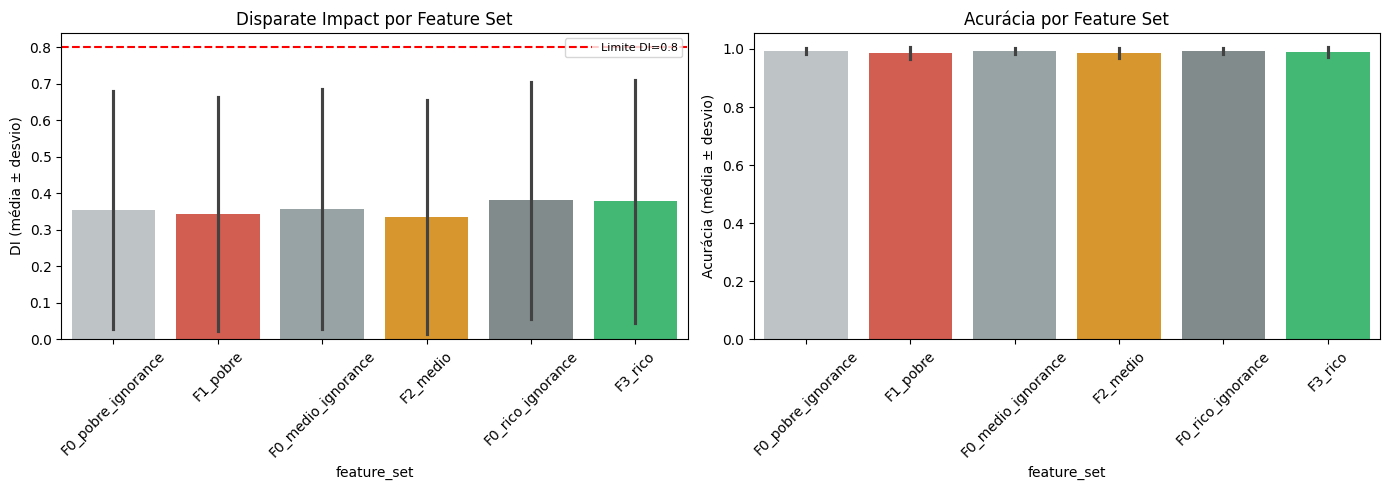

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
order = ['F0_pobre_ignorance', 'F1_pobre', 'F0_medio_ignorance', 'F2_medio', 'F0_rico_ignorance', 'F3_rico']
palette = {'F0_pobre_ignorance': '#bdc3c7', 'F1_pobre': '#e74c3c',
           'F0_medio_ignorance': '#95a5a6', 'F2_medio': '#f39c12',
           'F0_rico_ignorance': '#7f8c8d', 'F3_rico': '#2ecc71'}

sns.barplot(data=results_df, x='feature_set', y='di', order=order,
            errorbar='sd', palette=palette, ax=axes[0])
axes[0].axhline(0.8, color='red', linestyle='--', label='Limite DI=0.8')
axes[0].set_title('Disparate Impact por Feature Set')
axes[0].set_ylabel('DI (média ± desvio)')
axes[0].legend(fontsize=8)
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=results_df, x='feature_set', y='accuracy', order=order,
            errorbar='sd', palette=palette, ax=axes[1])
axes[1].set_title('Acurácia por Feature Set')
axes[1].set_ylabel('Acurácia (média ± desvio)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('barplot_di_acc.png', dpi=150)
plt.show()

##**7.2) Comparação pareada Ignorance vs Awareness**

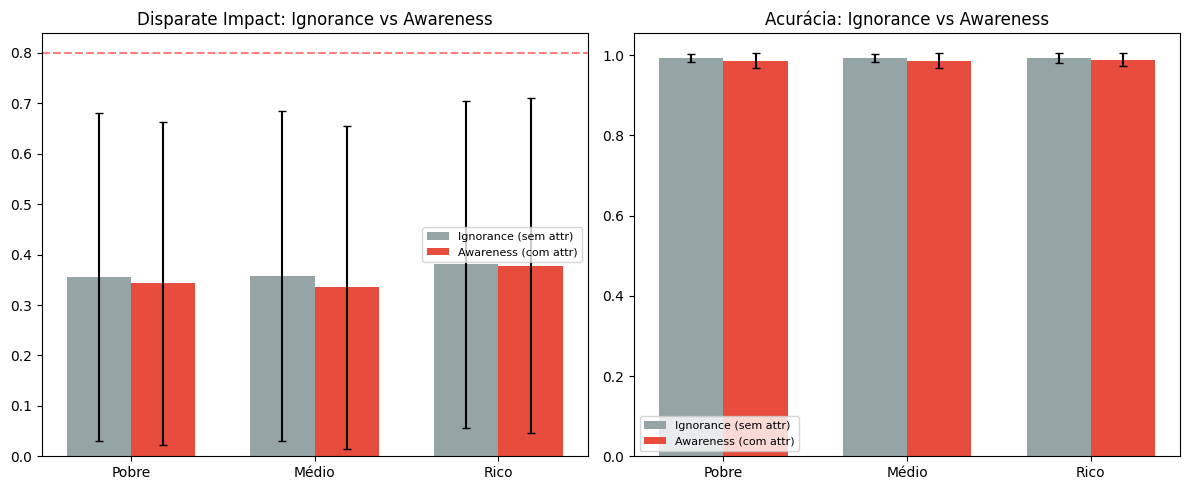

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
niveis = ['pobre', 'medio', 'rico']

for idx, (metrica, titulo) in enumerate([('di', 'Disparate Impact'), ('accuracy', 'Acurácia')]):
    x = np.arange(len(niveis))
    width = 0.35
    vals_ign, vals_awa, errs_ign, errs_awa = [], [], [], []
    for nivel in niveis:
        fs_ign = [k for k, v in ignorance_map.items() if v == (nivel, True)][0]
        fs_awa = [k for k, v in ignorance_map.items() if v == (nivel, False)][0]
        di = results_df[results_df['feature_set'] == fs_ign]
        da = results_df[results_df['feature_set'] == fs_awa]
        vals_ign.append(di[metrica].mean()); vals_awa.append(da[metrica].mean())
        errs_ign.append(di[metrica].std()); errs_awa.append(da[metrica].std())
    axes[idx].bar(x - width/2, vals_ign, width, yerr=errs_ign, label='Ignorance (sem attr)', color='#95a5a6', capsize=3)
    axes[idx].bar(x + width/2, vals_awa, width, yerr=errs_awa, label='Awareness (com attr)', color='#e74c3c', capsize=3)
    if metrica == 'di':
        axes[idx].axhline(0.8, color='red', linestyle='--', alpha=0.5)
    axes[idx].set_title(f'{titulo}: Ignorance vs Awareness')
    axes[idx].set_xticks(x)
    axes[idx].set_xticklabels(['Pobre', 'Médio', 'Rico'])
    axes[idx].legend(fontsize=8)

plt.tight_layout()
plt.savefig('ignorance_vs_awareness.png', dpi=150)
plt.show()

##**7.3) Heatmaps de DI — "Como os resultados variam em bases com mais e menos viés?"**

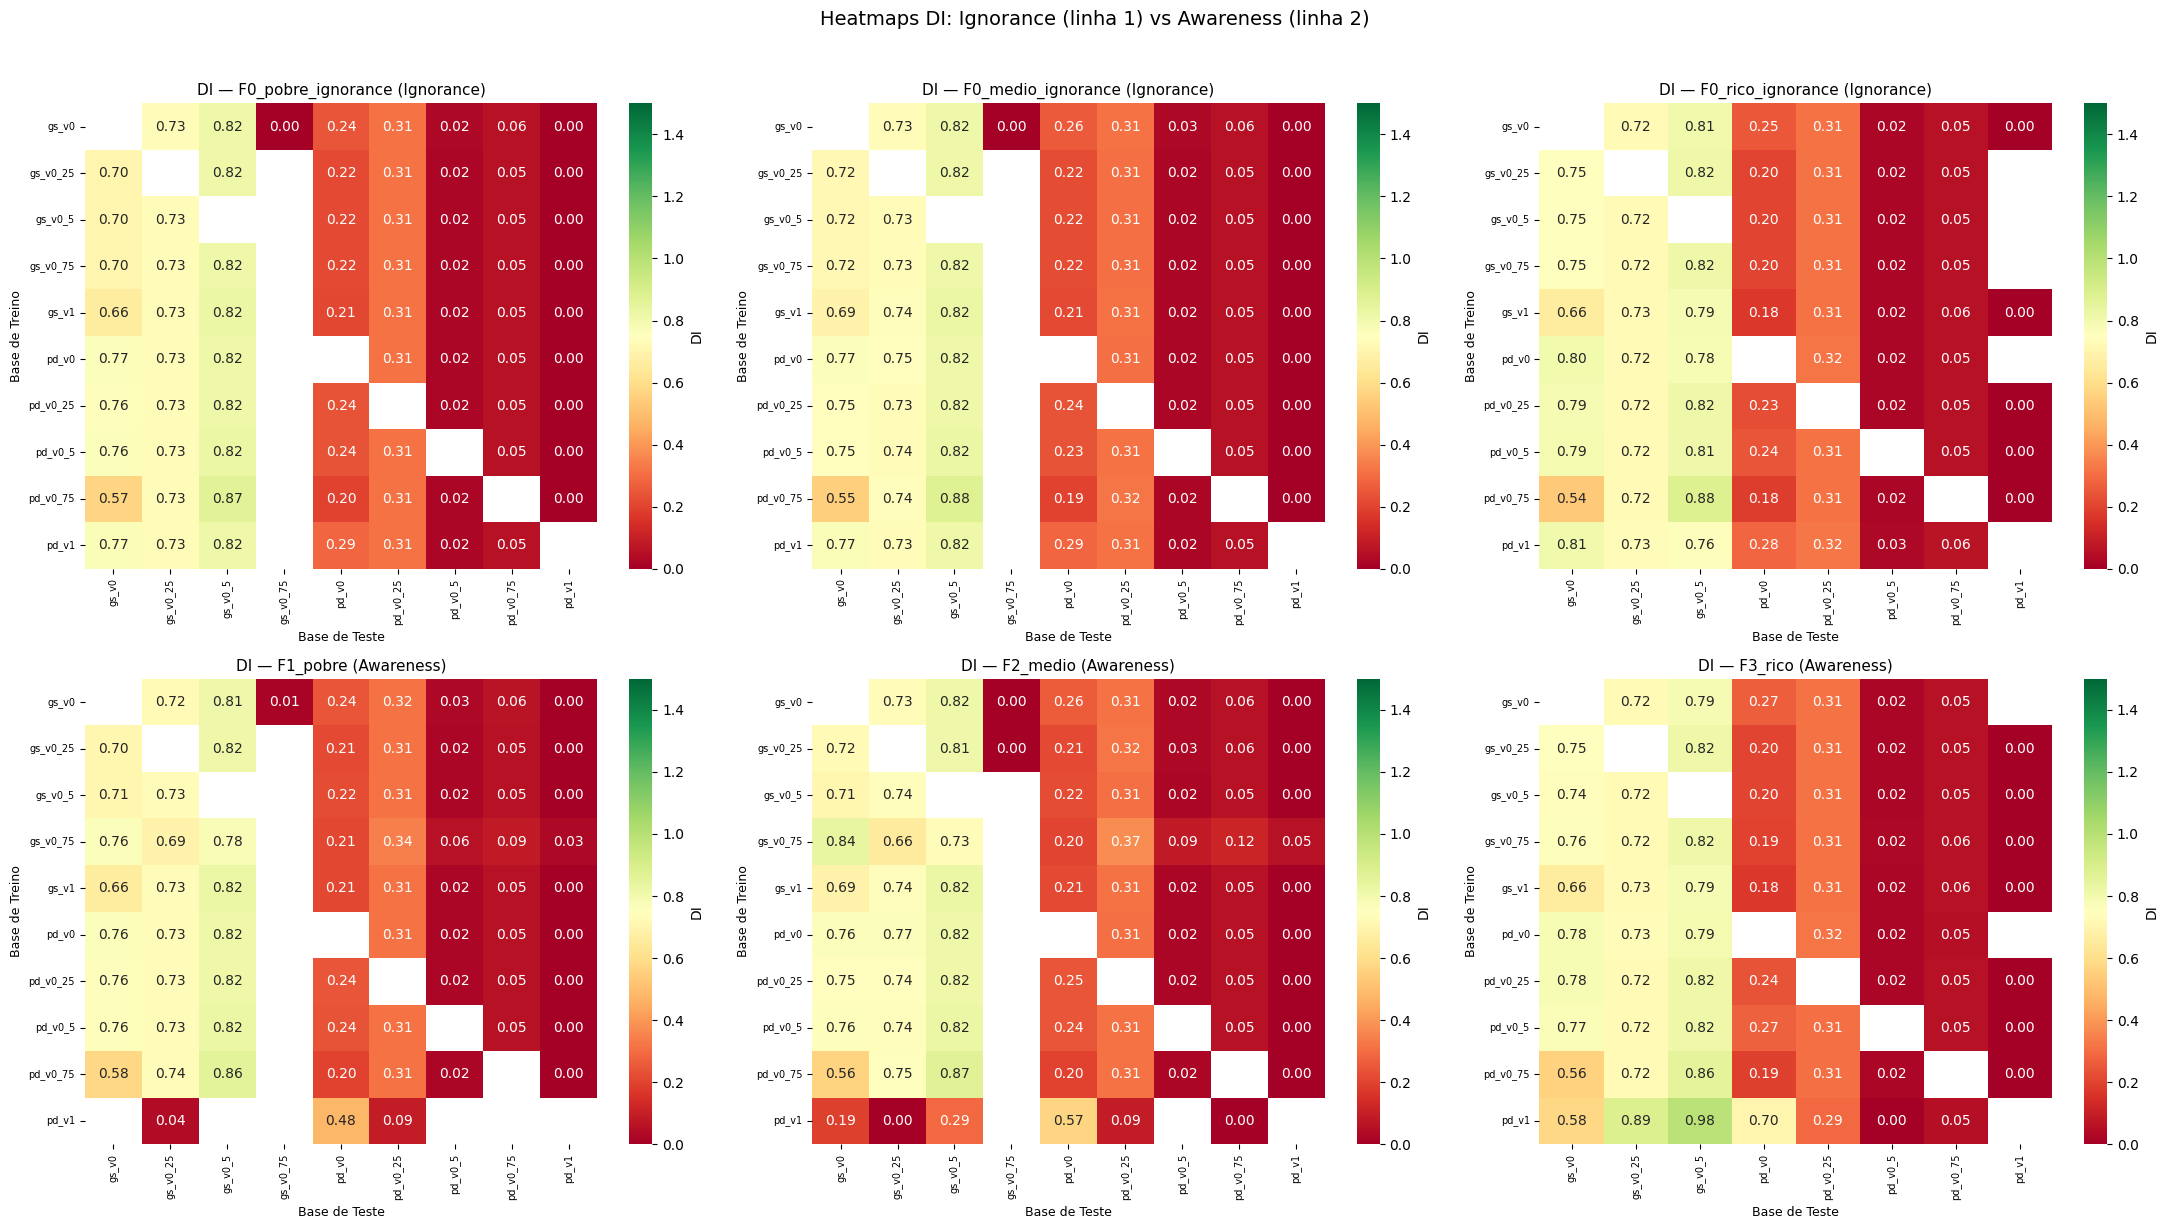

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(22, 12))
heatmap_order = ['F0_pobre_ignorance', 'F0_medio_ignorance', 'F0_rico_ignorance',
                 'F1_pobre', 'F2_medio', 'F3_rico']

for idx, feat_name in enumerate(heatmap_order):
    row, col = idx // 3, idx % 3
    ax = axes[row][col]
    pivot = results_df[results_df['feature_set'] == feat_name].pivot_table(
        index='train_base', columns='test_base', values='di')
    sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn', vmin=0, vmax=1.5, ax=ax,
                cbar_kws={'label': 'DI'})
    lbl = 'Ignorance' if 'ignorance' in feat_name else 'Awareness'
    ax.set_title(f'DI — {feat_name} ({lbl})', fontsize=11)
    ax.set_xlabel('Base de Teste', fontsize=9)
    ax.set_ylabel('Base de Treino', fontsize=9)
    ax.tick_params(axis='both', labelsize=7)

plt.suptitle('Heatmaps DI: Ignorance (linha 1) vs Awareness (linha 2)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('heatmaps_di.png', dpi=150, bbox_inches='tight')
plt.show()

##**7.4) Trade-off Acurácia vs DI (scatter)**

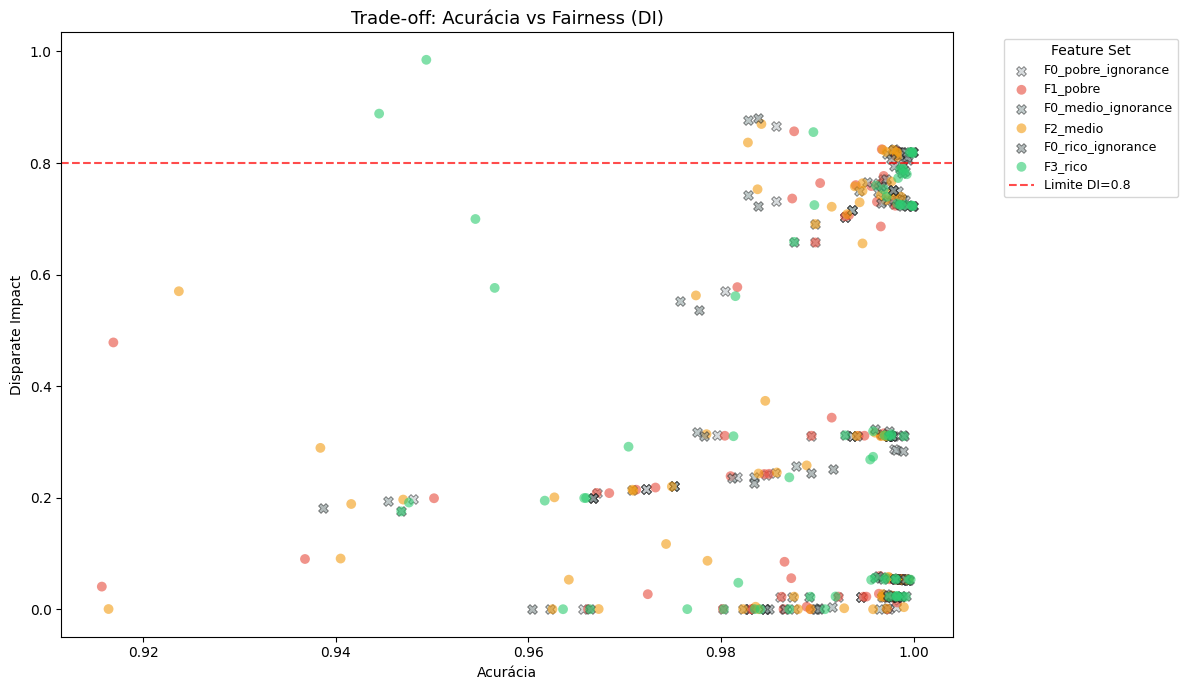

In [ ]:
plt.figure(figsize=(12, 7))
markers = {True: 'X', False: 'o'}
for feat_name in order:
    df_sub = results_df[results_df['feature_set'] == feat_name]
    is_ign = 'ignorance' in feat_name
    plt.scatter(df_sub['accuracy'], df_sub['di'], label=feat_name,
                color=palette[feat_name], marker=markers[is_ign],
                alpha=0.6, s=50, edgecolors='black' if is_ign else 'none', linewidths=0.5)
plt.axhline(0.8, color='red', linestyle='--', alpha=0.7, label='Limite DI=0.8')
plt.title('Trade-off: Acurácia vs Fairness (DI)', fontsize=13)
plt.xlabel('Acurácia')
plt.ylabel('Disparate Impact')
plt.legend(title='Feature Set', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('tradeoff_acc_vs_di.png', dpi=150, bbox_inches='tight')
plt.show()

##**7.5) Boxplot — Distribuição completa**

/tmp/ipykernel_779/2890651695.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=results_df, x='feature_set', y='di', order=order, palette=palette, ax=axes[0])
/tmp/ipykernel_779/2890651695.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=results_df, x='feature_set', y='accuracy', order=order, palette=palette, ax=axes[1])


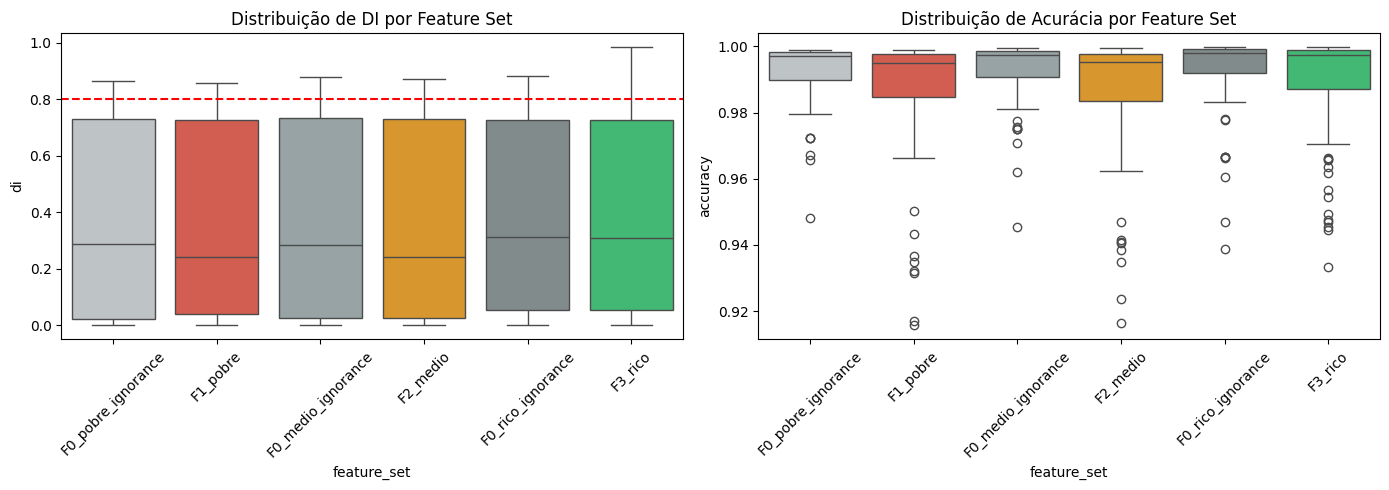

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=results_df, x='feature_set', y='di', order=order, palette=palette, ax=axes[0])
axes[0].axhline(0.8, color='red', linestyle='--')
axes[0].set_title('Distribuição de DI por Feature Set')
axes[0].tick_params(axis='x', rotation=45)
sns.boxplot(data=results_df, x='feature_set', y='accuracy', order=order, palette=palette, ax=axes[1])
axes[1].set_title('Distribuição de Acurácia por Feature Set')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('boxplot_di_acc.png', dpi=150)
plt.show()